# 🤖 Transformer in TensorFlow
## Month 1 Day 2 — Building Transformer with Keras
**Goal:** Rebuild yesterday's NumPy transformer using TensorFlow/Keras
**Then:** Train it on Shakespeare text to generate new text!

### Today's Plan:
1. Positional Encoding Layer
2. Encoder Block
3. Decoder Block  
4. Full Transformer Model
5. Train on Shakespeare
6. Generate new text!

In [1]:

#  Imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
plt.style.use('seaborn-v0_8')

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.19.0
Keras      : 3.13.2
NumPy      : 2.0.2
GPU available: True


In [2]:
#  Hyperparameters
# These match the original transformer paper
# (scaled down for CPU training)

D_MODEL   = 128    # embedding dimension
                   # (paper uses 512, we use 128 for speed)
NUM_HEADS = 8      # attention heads
                   # d_model must be divisible by num_heads!
D_FF      = 512    # feed-forward hidden dim
                   # (paper uses 2048, we use 512)
NUM_LAYERS= 2      # number of encoder/decoder blocks
                   # (paper uses 6, we use 2 for speed)
DROPOUT   = 0.1    # dropout rate
SEQ_LEN   = 64     # sequence length for training
BATCH_SIZE= 64     # samples per training step
EPOCHS    = 15     # training epochs

print("Hyperparameters:")
print(f"  D_MODEL    = {D_MODEL}")
print(f"  NUM_HEADS  = {NUM_HEADS}")
print(f"  D_FF       = {D_FF}")
print(f"  NUM_LAYERS = {NUM_LAYERS}")
print(f"  d_k per head = {D_MODEL // NUM_HEADS}")
print(f"  SEQ_LEN    = {SEQ_LEN}")

Hyperparameters:
  D_MODEL    = 128
  NUM_HEADS  = 8
  D_FF       = 512
  NUM_LAYERS = 2
  d_k per head = 16
  SEQ_LEN    = 64


In [3]:
# Load Shakespeare Dataset
# TensorFlow has this built in!
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

# Read the text
text = open(path, 'rb').read().decode(encoding='utf-8')

print(f"Total characters : {len(text):,}")
print(f"First 200 chars  :\n{text[:200]}")

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Total characters : 1,115,394
First 200 chars  :
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [4]:
# Character Level Tokenization
# Get all unique characters
vocab = sorted(set(text))
print(f"Vocabulary size  : {len(vocab)}")
print(f"Vocabulary       : {''.join(vocab[:30])}...")

# Create character to index mapping
char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = np.array(vocab)

# Convert entire text to numbers
text_as_int = np.array([char2idx[c] for c in text])

print(f"\nText as integers (first 20):")
print(text_as_int[:20])
print(f"\nDecoded back:")
print(''.join(idx2char[text_as_int[:20]]))

VOCAB_SIZE = len(vocab)
print(f"\nVOCAB_SIZE = {VOCAB_SIZE}")

Vocabulary size  : 65
Vocabulary       : 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQ...

Text as integers (first 20):
[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]

Decoded back:
First Citizen:
Befor

VOCAB_SIZE = 65


In [5]:
# Create Training Sequences
# Input:  "To be or not to b"  (64 chars)
# Target: "o be or not to be" (64 chars, shifted by 1)

def create_sequences(text_as_int, seq_len):
    """
    Create overlapping sequences for training.
    Each sequence is SEQ_LEN+1 chars long.
    First SEQ_LEN chars = input
    Last  SEQ_LEN chars = target (shifted by 1)
    """
    sequences = []
    for i in range(0, len(text_as_int) - seq_len - 1, 3):
        seq = text_as_int[i : i + seq_len + 1]
        sequences.append(seq)
    return np.array(sequences)

sequences = create_sequences(text_as_int, SEQ_LEN)
print(f"Total sequences : {len(sequences):,}")
print(f"Sequence shape  : {sequences.shape}")

# Split into input and target
X = sequences[:, :-1]   # all except last char
y = sequences[:, 1:]    # all except first char

print(f"\nX shape: {X.shape}  (input)")
print(f"y shape: {y.shape}  (target)")
print(f"\nExample:")
print(f"Input : {''.join(idx2char[X[0]])}")
print(f"Target: {''.join(idx2char[y[0]])}")

Total sequences : 371,777
Sequence shape  : (371777, 65)

X shape: (371777, 64)  (input)
y shape: (371777, 64)  (target)

Example:
Input : First Citizen:
Before we proceed any further, hear me speak.

Al
Target: irst Citizen:
Before we proceed any further, hear me speak.

All


In [6]:
# Create TensorFlow Dataset
# tf.data.Dataset is faster than numpy arrays
# for training — handles batching, shuffling
# and prefetching automatically!

BUFFER_SIZE = 10000  # shuffle buffer

dataset = tf.data.Dataset.from_tensor_slices((X, y))

# Shuffle → Batch → Prefetch
dataset = dataset\
    .shuffle(BUFFER_SIZE)\
    .batch(BATCH_SIZE, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)

# Count batches
num_batches = len(list(dataset))
print(f"Batch size     : {BATCH_SIZE}")
print(f"Total batches  : {num_batches:,}")
print(f"Steps per epoch: {num_batches:,}")

# Check one batch
for x_batch, y_batch in dataset.take(1):
    print(f"\nX batch shape: {x_batch.shape}")
    print(f"y batch shape: {y_batch.shape}")

Batch size     : 64
Total batches  : 5,809
Steps per epoch: 5,809

X batch shape: (64, 64)
y batch shape: (64, 64)


In [7]:
# Create TensorFlow Dataset
# tf.data.Dataset is faster than numpy arrays
# for training — handles batching, shuffling
# and prefetching automatically!

BUFFER_SIZE = 10000  # shuffle buffer

dataset = tf.data.Dataset.from_tensor_slices((X, y))

# Shuffle → Batch → Prefetch
dataset = dataset\
    .shuffle(BUFFER_SIZE)\
    .batch(BATCH_SIZE, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)

# Count batches
num_batches = len(list(dataset))
print(f"Batch size     : {BATCH_SIZE}")
print(f"Total batches  : {num_batches:,}")
print(f"Steps per epoch: {num_batches:,}")

# Check one batch
for x_batch, y_batch in dataset.take(1):
    print(f"\nX batch shape: {x_batch.shape}")
    print(f"y batch shape: {y_batch.shape}")

Batch size     : 64
Total batches  : 5,809
Steps per epoch: 5,809

X batch shape: (64, 64)
y batch shape: (64, 64)


In [8]:
# Positional Encoding Layer
# Same math as yesterday's NumPy version
# but now as a proper TF layer!

class PositionalEncoding(layers.Layer):
    """
    Adds positional information to embeddings.
    Inherits from layers.Layer so it integrates
    with Keras model training automatically.
    """

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model

        # Compute PE matrix once in __init__
        # Shape: (max_len, d_model)
        PE = np.zeros((max_len, d_model))

        for pos in range(max_len):
            for i in range(0, d_model, 2):
                PE[pos, i] = np.sin(
                    pos / (10000 ** (2*i / d_model))
                )
                if i + 1 < d_model:
                    PE[pos, i+1] = np.cos(
                        pos / (10000 ** (2*i / d_model))
                    )

        # Add batch dimension: (1, max_len, d_model)
        # so it broadcasts correctly with input
        self.PE = tf.cast(
            PE[np.newaxis, :, :], dtype=tf.float32
        )

    def call(self, x):
        """
        Args:
            x: input embeddings (batch, seq_len, d_model)

        Returns:
            x + positional encoding
        """
        seq_len = tf.shape(x)[1]
        # Slice PE to match sequence length
        return x + self.PE[:, :seq_len, :]


# ── Test it ───────────────────────────────────
pe    = PositionalEncoding(D_MODEL)
test  = tf.zeros((2, SEQ_LEN, D_MODEL))
output= pe(test)

print(f"PE input  shape: {test.shape}")
print(f"PE output shape: {output.shape}")
print("Positional Encoding layer working! ✅")

PE input  shape: (2, 64, 128)
PE output shape: (2, 64, 128)
Positional Encoding layer working! ✅


In [9]:
# Encoder Block
class EncoderBlock(layers.Layer):
    """
    Single Encoder Block.

    Structure:
    Input
      → Multi-Head Self-Attention
      → Add & Norm
      → Feed-Forward Network
      → Add & Norm
    Output
    """

    def __init__(self, d_model, num_heads, d_ff,
                 dropout=0.1):
        super().__init__()

        # Multi-Head Self-Attention
        # key_dim = d_model // num_heads = 16
        self.attention = layers.MultiHeadAttention(
            num_heads = num_heads,
            key_dim   = d_model // num_heads,
            dropout   = dropout
        )

        # Feed-Forward Network
        # Two Dense layers: expand then compress
        self.ffn = keras.Sequential([
            layers.Dense(d_ff, activation='relu'),
            layers.Dense(d_model)
        ])

        # Layer Normalization
        self.norm1 = layers.LayerNormalization(
                         epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(
                         epsilon=1e-6)

        # Dropout for regularization
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        """
        Args:
            x       : input (batch, seq_len, d_model)
            training : True during training,
                       False during inference
                       (controls dropout!)

        Returns:
            output (batch, seq_len, d_model)
        """
        # ── Sub-layer 1: Self-Attention ────────
        # Q = K = V = x (self-attention!)
        # use_causal_mask=False for encoder
        # (encoder sees full input sequence)
        attn_output = self.attention(
            query = x,
            value = x,
            key   = x,
            training = training
        )
        attn_output = self.dropout1(
            attn_output, training=training)

        # Add & Norm (residual connection)
        x = self.norm1(x + attn_output)

        # ── Sub-layer 2: Feed-Forward ──────────
        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(
            ffn_output, training=training)

        # Add & Norm
        x = self.norm2(x + ffn_output)

        return x


# ── Test it ───────────────────────────────────
enc_block = EncoderBlock(D_MODEL, NUM_HEADS, D_FF)
test      = tf.random.uniform((2, SEQ_LEN, D_MODEL))
output    = enc_block(test, training=False)

print(f"Encoder input  shape: {test.shape}")
print(f"Encoder output shape: {output.shape}")
print("Encoder Block working! ✅")

Encoder input  shape: (2, 64, 128)
Encoder output shape: (2, 64, 128)
Encoder Block working! ✅


In [10]:
# Decoder Block
class DecoderBlock(layers.Layer):
    """
    Single Decoder Block.

    Structure:
    Input
      → Masked Multi-Head Self-Attention
      → Add & Norm
      → Cross-Attention (encoder-decoder)
      → Add & Norm
      → Feed-Forward Network
      → Add & Norm
    Output

    Key difference from Encoder:
    1. Masked self-attention (can't see future)
    2. Cross-attention (reads encoder output)
    """

    def __init__(self, d_model, num_heads, d_ff,
                 dropout=0.1):
        super().__init__()

        # 1. Masked Self-Attention
        self.masked_attention = layers.MultiHeadAttention(
            num_heads = num_heads,
            key_dim   = d_model // num_heads,
            dropout   = dropout
        )

        # 2. Cross-Attention
        self.cross_attention = layers.MultiHeadAttention(
            num_heads = num_heads,
            key_dim   = d_model // num_heads,
            dropout   = dropout
        )

        # Feed-Forward Network
        self.ffn = keras.Sequential([
            layers.Dense(d_ff, activation='relu'),
            layers.Dense(d_model)
        ])

        # 3 Layer Norms (one per sublayer)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)

        # Dropout
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)

    def call(self, x, encoder_output, training=False):
        """
        Args:
            x             : target (batch, tgt_len, d_model)
            encoder_output: (batch, src_len, d_model)
            training      : controls dropout

        Returns:
            output (batch, tgt_len, d_model)
        """
        # ── Sub-layer 1: Masked Self-Attention ─
        # use_causal_mask=True → can't see future!
        # This is the KEY difference from encoder
        masked_attn = self.masked_attention(
            query          = x,
            value          = x,
            key            = x,
            use_causal_mask= True,   # mask future tokens!
            training       = training
        )
        masked_attn = self.dropout1(
            masked_attn, training=training)
        x = self.norm1(x + masked_attn)

        # ── Sub-layer 2: Cross-Attention ───────
        # Q from decoder, K and V from encoder!
        cross_attn = self.cross_attention(
            query    = x,               # from decoder
            value    = encoder_output,  # from encoder
            key      = encoder_output,  # from encoder
            training = training
        )
        cross_attn = self.dropout2(
            cross_attn, training=training)
        x = self.norm2(x + cross_attn)

        # ── Sub-layer 3: Feed-Forward ──────────
        ffn_output = self.ffn(x)
        ffn_output = self.dropout3(
            ffn_output, training=training)
        x = self.norm3(x + ffn_output)

        return x


# ── Test it ───────────────────────────────────
dec_block      = DecoderBlock(D_MODEL, NUM_HEADS, D_FF)
tgt            = tf.random.uniform((2, SEQ_LEN, D_MODEL))
encoder_output = tf.random.uniform((2, SEQ_LEN, D_MODEL))
output         = dec_block(tgt, encoder_output,
                           training=False)

print(f"Decoder input  shape: {tgt.shape}")
print(f"Encoder output shape: {encoder_output.shape}")
print(f"Decoder output shape: {output.shape}")
print("Decoder Block working! ✅")

Decoder input  shape: (2, 64, 128)
Encoder output shape: (2, 64, 128)
Decoder output shape: (2, 64, 128)
Decoder Block working! ✅


In [11]:
# ── Full Transformer Model ────────────────────
class Transformer(keras.Model):
    """
    Full Transformer Model for language modeling.

    For character-level text generation:
    Input:  sequence of character indices
    Output: probability distribution over vocab
            for next character at each position

    Architecture:
    Input indices
      → Embedding (indices → dense vectors)
      → Positional Encoding
      → N × Encoder Blocks
      → N × Decoder Blocks
      → Dense(vocab_size) + Softmax
      → Next character probabilities
    """

    def __init__(self, vocab_size, d_model,
                 num_heads, d_ff, num_layers,
                 dropout=0.1, max_len=5000):
        super().__init__()

        self.d_model    = d_model
        self.num_layers = num_layers

        # ── Embedding ─────────────────────────
        # Converts token indices → dense vectors
        # vocab_size = 65 (Shakespeare chars)
        # d_model    = 128 (embedding dimension)
        self.embedding = layers.Embedding(
            input_dim  = vocab_size,
            output_dim = d_model
        )

        # ── Positional Encoding ───────────────
        self.pos_encoding = PositionalEncoding(
            d_model, max_len
        )

        # ── Dropout ───────────────────────────
        self.dropout = layers.Dropout(dropout)

        # ── Encoder Blocks ────────────────────
        # N stacked encoder blocks
        self.encoder_blocks = [
            EncoderBlock(d_model, num_heads,
                         d_ff, dropout)
            for _ in range(num_layers)
        ]

        # ── Decoder Blocks ────────────────────
        # N stacked decoder blocks
        self.decoder_blocks = [
            DecoderBlock(d_model, num_heads,
                         d_ff, dropout)
            for _ in range(num_layers)
        ]

        # ── Output Layer ──────────────────────
        # Project from d_model → vocab_size
        # No activation here — we use
        # SparseCategoricalCrossentropy
        # with from_logits=True
        self.output_layer = layers.Dense(vocab_size)

    def call(self, x, training=False):
        """
        Forward pass.

        For simplicity we use same sequence
        for both encoder and decoder input.
        (decoder-only style like GPT!)

        Args:
            x       : input indices (batch, seq_len)
            training: controls dropout

        Returns:
            logits (batch, seq_len, vocab_size)
        """
        # ── Step 1: Embedding ─────────────────
        # (batch, seq_len) → (batch, seq_len, d_model)
        x = self.embedding(x)

        # Scale embeddings by √d_model
        # (from original paper)
        x = x * tf.math.sqrt(
                tf.cast(self.d_model, tf.float32))

        # ── Step 2: Positional Encoding ───────
        x = self.pos_encoding(x)
        x = self.dropout(x, training=training)

        # ── Step 3: Encoder ───────────────────
        encoder_output = x
        for encoder_block in self.encoder_blocks:
            encoder_output = encoder_block(
                encoder_output, training=training
            )

        # ── Step 4: Decoder ───────────────────
        decoder_output = x
        for decoder_block in self.decoder_blocks:
            decoder_output = decoder_block(
                decoder_output,
                encoder_output,
                training=training
            )

        # ── Step 5: Output projection ─────────
        # (batch, seq_len, d_model)
        # → (batch, seq_len, vocab_size)
        logits = self.output_layer(decoder_output)

        return logits


# ── Build and test model ──────────────────────
model = Transformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    d_ff        = D_FF,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
)

# Test forward pass
test_input = tf.random.uniform(
    (2, SEQ_LEN), minval=0,
    maxval=VOCAB_SIZE, dtype=tf.int32
)
test_output = model(test_input, training=False)

print(f"Input  shape : {test_input.shape}")
print(f"Output shape : {test_output.shape}")
print(f"Vocab size   : {VOCAB_SIZE}")
print("Full Transformer working! ✅")

Input  shape : (2, 64)
Output shape : (2, 64, 65)
Vocab size   : 65
Full Transformer working! ✅


In [12]:
# ── Model Summary ─────────────────────────────
# Build model by passing dummy input
model(tf.zeros((1, SEQ_LEN), dtype=tf.int32))
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Approx size     : {total_params * 4 / 1e6:.1f} MB")

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (2, 64, 128)           │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ ?                      │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_block_1 (EncoderBlock)  │ ?                      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_block_2 (EncoderBlock)  │ ?                      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_1 (DecoderBlock)  │ ?                      │       264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_2 (DecoderBlock)  │ ?                      │       264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (2, 64, 65)            │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,401 (3.59 MB)

 Trainable params: 942,401 (3.59 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 942,401
Approx size     : 3.8 MB


In [13]:
# ── Compile Model ─────────────────────────────
model.compile(
    optimizer = keras.optimizers.Adam(
                    learning_rate=0.001),
    loss      = keras.losses.SparseCategoricalCrossentropy(
                    from_logits=True),
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor  = 'loss',
        patience = 3,
        restore_best_weights = True,
        verbose  = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = 'loss',
        factor   = 0.5,
        patience = 2,
        verbose  = 1
    )
]

# ── Train ─────────────────────────────────────
print("Training Transformer on Shakespeare...")
print(f"Epochs     : {EPOCHS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Batches/epoch: {num_batches:,}")
print("This will take ~10-15 minutes on CPU...")

history = model.fit(
    dataset,
    epochs    = EPOCHS,
    callbacks = callbacks,
    verbose   = 1
)

Training Transformer on Shakespeare...
Epochs     : 15
Batch size : 64
Batches/epoch: 5,809
This will take ~10-15 minutes on CPU...
Epoch 1/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 166s 24ms/step - accuracy: 0.9500 - loss: 0.1705 - learning_rate: 0.0010
Epoch 2/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 138s 24ms/step - accuracy: 0.9901 - loss: 0.0343 - learning_rate: 0.0010
Epoch 3/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 133s 23ms/step - accuracy: 0.9908 - loss: 0.0317 - learning_rate: 0.0010
Epoch 4/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 134s 23ms/step - accuracy: 0.9912 - loss: 0.0302 - learning_rate: 0.0010
Epoch 5/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 135s 23ms/step - accuracy: 0.9914 - loss: 0.0292 - learning_rate: 0.0010
Epoch 6/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 135s 23ms/step - accuracy: 0.9916 - loss: 0.0285 - learning_rate: 0.0010
Epoch 7/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 137s 24ms/step - accuracy: 0.9917 - loss: 0.0280 - learning_rate: 0.0010
Epoch 8/15
5809/5809 ━━━━━━━━━━━━━━━━━━━━ 133s 23ms/step - accu

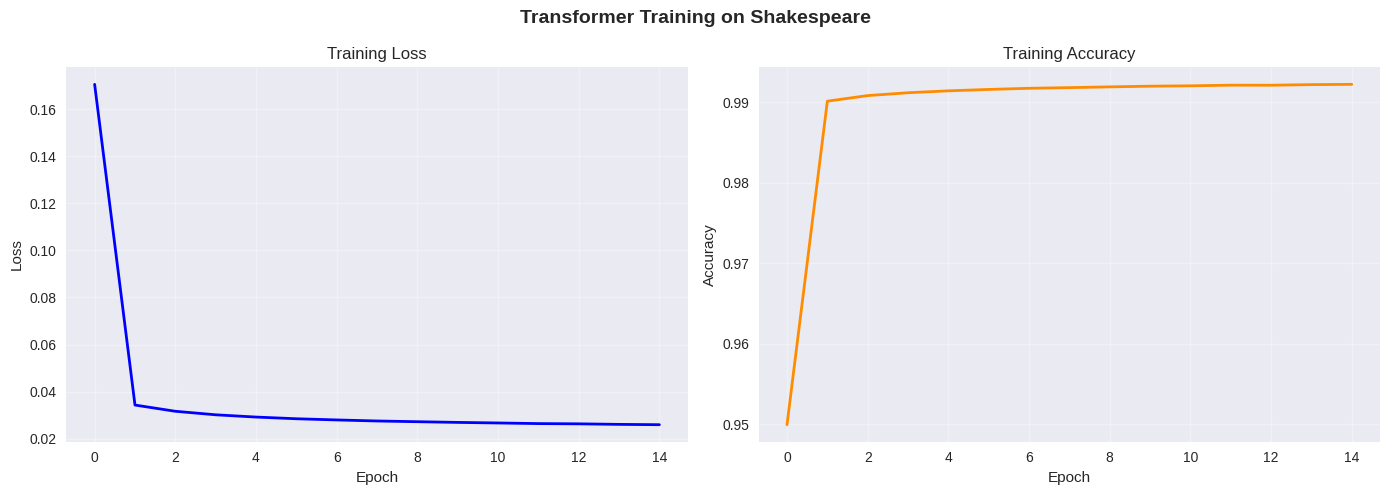

In [14]:
# ── Plot Training History ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],
             color='blue', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],
             color='darkorange', linewidth=2)
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transformer Training on Shakespeare',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── Text Generation ───────────────────────────
def generate_text(model, start_string,
                  num_generate=200,
                  temperature=1.0):
    """
    Generate new Shakespeare-style text!

    Temperature controls randomness:
    Low  (0.2) → predictable, repetitive
    High (1.5) → creative, random
    Best (1.0) → balanced
    """
    # Convert start string to indices
    input_indices = [char2idx[c] for c in start_string
                     if c in char2idx]
    input_indices = tf.expand_dims(input_indices, 0)

    generated = []

    for i in range(num_generate):
        # Get predictions
        predictions = model(input_indices, training=False)

        # Take last token predictions only
        predictions = predictions[:, -1, :]

        # Apply temperature
        predictions = predictions / temperature

        # Sample from distribution
        predicted_id = tf.random.categorical(
            predictions, num_samples=1
        )
        predicted_id = predicted_id.numpy()[0][0]

        # Add to generated list
        generated.append(idx2char[predicted_id])

        # Update input sequence
        input_indices = tf.concat([
            input_indices,
            [[predicted_id]]
        ], axis=1)

        # Keep sequence length manageable
        if input_indices.shape[1] > SEQ_LEN:
            input_indices = input_indices[:, -SEQ_LEN:]

    return start_string + ''.join(generated)

In [16]:
# ── Generate Shakespeare Text ─────────────────
seeds = [
    "ROMEO: ",
    "JULIET: ",
    "To be or not to be",
    "KING: "
]

temperatures = [0.2, 0.5, 1.0, 1.2]

for seed in seeds:
    print("=" * 55)
    print(f"SEED: '{seed}'")
    print("=" * 55)
    for temp in temperatures:
        print(f"\n-- Temperature: {temp} --")
        text = generate_text(
            model,
            start_string = seed,
            num_generate = 200,
            temperature  = temp
        )
        print(text)
    print()

SEED: 'ROMEO: '

-- Temperature: 0.2 --
ROMEO:                       ooooooooooooooooooooooooooooooooooon
The soul should be his with a some of the part
The shall be as a day the some of the do not
The some the did and the shall for the brother,
A

-- Temperature: 0.5 --
ROMEO:               fffffffffffffffffffffffffffffffffffffffffff,
Than here safter and thee is his was as a of thee
The with prison in the sease and the do a lack,
Which may her you.

ADRANDA:
Ay, what is a 

-- Temperature: 1.0 --
ROMEO: tttttttttttttttttttttttt;









PROOOOOOOOOOOOOOOOOOOLY:
AgaA:
Subh inster'd, not, wash know thou 'mat,
For save seet as be ae speak me the husband.

GREMIO:
Why, they burn come or eitured perce er

-- Temperature: 1.2 --
ROMEO: oooooooooooooooooooorrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrry;
For why! Sailtor?

JUKE VINCENTIO:
Which, thee know begid our endorsman,
Father! Ruchards I am do chapeshiar jest teable,
But thy does thru 

SEED: 'JULIET: '

-- Temperature: 0.2 --
JULIET:       